---

# **Taller de K-Means con Métodos de Verificación**
## Clustering sobre datos sintéticos en 2D

### **Integrantes:** Alan Gracia, Alejandra Restrepo y Gabriel Caicedo

---

### Objetivo del taller

Diseñar e implementar un algoritmo de **K-Means** que reciba como entrada un conjunto de datos sintéticos en dos dimensiones, compuesto por **seis grupos (clusters)** con las siguientes características:

1. **Generados aleatoriamente**, siguiendo distribuciones **gaussianas isotrópicas** (misma varianza en todas las direcciones).
2. Con **diferentes densidades**: mismo número de puntos por grupo, pero **diferente desviación estándar**.
3. Todos los valores, al visualizar los seis grupos, deben estar **contenidos entre -10 y 10** en ambos ejes.
4. **Dos de los grupos** deben estar **cercanos entre sí**, **superponiéndose parcialmente**.
5. Se deben agregar **outliers** (valores atípicos) que sigan una **distribución uniforme entre -10 y 10** en ambos ejes.

Una vez generados los datos, se debe:

- **Remover los outliers** antes de aplicar el clustering.
- **Explorar entre 2 y 12 grupos** (valores de *K*).
- Aplicar el **método de Silhouette** para determinar el número óptimo de grupos.
- Aplicar el **método del codo (Elbow)** para determinar el número óptimo de grupos.
- Aplicar un **método basado en las etiquetas verdaderas (ground truth)** para determinar el número óptimo de grupos.

---

### Estructura del notebook

1. Fundamentos de K-Means (breve repaso).
2. Generación del dataset sintético (6 clusters + outliers).
3. Remoción de outliers (preprocesamiento).
4. Exploración de K-Means para *K* = 2 a 12.
5. Selección del número óptimo de clusters: **Codo**, **Silhouette** y **Ground Truth**.
6. Comparación de los tres métodos y resultado final.
7. Conclusiones.

---


## 1. Repaso rápido: ¿qué es K-Means?

**K-Means** es un algoritmo de *clustering* (aprendizaje no supervisado) que agrupa un conjunto de datos en **K** grupos, de tal manera que cada punto pertenece al grupo cuyo **centroide** (promedio de los puntos del grupo) es el más cercano.

**Pasos del algoritmo:**

1. Elegir el número de clusters **K**.
2. Inicializar **K** centroides (K-Means++ por defecto en scikit-learn).
3. Asignar cada punto al centroide más cercano (distancia euclidiana).
4. Recalcular cada centroide como el promedio de los puntos asignados.
5. Repetir los pasos 3 y 4 hasta que los centroides ya no cambien significativamente (convergencia).

**Supuestos importantes de K-Means** (relevantes para este taller):

- Los clusters deben ser aproximadamente **esféricos** (isotrópicos) y de tamaño similar.
- Es **sensible a outliers**, porque estos pueden desplazar fuertemente la posición de los centroides.
- Requiere que el número de clusters **K** sea definido de antemano — por eso necesitamos métodos para estimarlo (Codo, Silhouette, y comparación con ground truth).

---


In [159]:
# Importación de librerías
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.neighbors import LocalOutlierFactor
from sklearn.metrics import (
    silhouette_score,
    silhouette_samples,
    adjusted_rand_score,
    normalized_mutual_info_score,
    confusion_matrix,
)
from scipy.optimize import linear_sum_assignment

# Semilla para reproducibilidad
RANDOM_STATE = 40
np.random.seed(RANDOM_STATE)

plt.rcParams["figure.figsize"] = (7, 6)


## 2. Generación del dataset sintético

### 2.1 Especificaciones de diseño

Vamos a construir el dataset usando `sklearn.datasets.make_blobs`, pasándole como parámetros un **array de centros** (`centers`) y un **array de desviaciones estándar** (`cluster_std`), uno por cada uno de los 6 clusters. Esto nos da control total sobre cada requisito del taller, con la ventaja de apoyarnos en una función ya validada de scikit-learn:

| Requisito | Cómo se cumple |
|---|---|
| 6 grupos gaussianos isotrópicos | Para cada cluster generamos `x = N(cx, σ)` y `y = N(cy, σ)` con la **misma σ** en ambos ejes (isotrópico) |
| Diferentes densidades | Todos los clusters tienen el **mismo número de puntos** (`n_por_cluster`), pero **diferente desviación estándar** `σ_i`. A igual número de puntos, un σ menor implica más puntos por unidad de área → mayor densidad |
| Todo entre -10 y 10 | Elegimos centros y σ conservadores, y aplicamos un `clip` final de seguridad a `[-10, 10]` |
| 2 grupos cercanos y solapados | Los clusters 5 y 6 se ubican con centros cercanos y radios (σ) que hacen que sus "nubes" de puntos se toquen y mezclen parcialmente |
| Outliers uniformes | Puntos adicionales `Uniform(-10, 10)` en ambos ejes, con una etiqueta especial (`-1`) que **no corresponde a ningún cluster real** |

### 2.2 Código de generación


In [160]:
# --------------------------------------------------------------
# Parámetros de los 6 clusters (isotrópicos: misma sigma en X e Y)
# Se definen como arrays y se pasan directamente a make_blobs
# --------------------------------------------------------------
centros = np.array([
    [-6.5,  6.5],   # cluster 0 - esquina superior izquierda
    [-6.5, -6.5],   # cluster 1 - esquina inferior izquierda
    [ 6.5,  6.5],   # cluster 2 - esquina superior derecha
    [ 6.5, -6.5],   # cluster 3 - esquina inferior derecha
    [-1.0,  0.3],   # cluster 4 - par superpuesto (A)
    [ 1.4, -0.2],   # cluster 5 - par superpuesto (B), cercano al cluster 4
])

# Diferentes desviaciones estándar -> diferentes densidades
# (mismo número de puntos, pero "nubes" más o menos compactas)
sigmas = np.array([0.45, 0.75, 0.55, 0.85, 0.45, 0.65])

n_clusters_verdaderos = len(centros)
n_por_cluster = 250          # mismo número de puntos en cada cluster
n_outliers = 150             # cantidad de outliers a agregar

# --------------------------------------------------------------
# make_blobs recibe:
#   - centers: array (n_clusters, 2) con el centro de cada cluster
#   - cluster_std: array (n_clusters,) con la sigma de cada cluster
#   - n_samples: si se pasa un solo entero, make_blobs lo reparte
#     como TOTAL entre todos los clusters, no por cluster. Para
#     garantizar el mismo número de puntos EN CADA cluster, se
#     pasa explícitamente una lista con n_por_cluster repetido
#     una vez por cada centro.
# Al pasar un array de sigmas (no un único valor), cada cluster
# conserva su propia dispersión -> clusters isotrópicos
# (misma sigma en X e Y dentro de cada uno) pero con distinta
# densidad entre sí.
# --------------------------------------------------------------
n_samples_por_cluster = [n_por_cluster] * len(centros)

X_clusters, y_clusters = make_blobs(
    n_samples=n_samples_por_cluster,  # lista: mismo n en cada cluster
    centers=centros,                  # array de centros (6, 2)
    cluster_std=sigmas,               # array de sigmas (6,)
    n_features=2,
    random_state=RANDOM_STATE,
)

# --------------------------------------------------------------
# Outliers: distribución UNIFORME en [-10, 10] x [-10, 10]
# Se etiquetan con -1 porque no pertenecen a ningún cluster real
# --------------------------------------------------------------
X_outliers = np.random.uniform(low=-10, high=10, size=(n_outliers, 2))
y_outliers = np.full(n_outliers, -1)

# --------------------------------------------------------------
# Dataset completo = clusters + outliers, y se mezclan (shuffle)
# --------------------------------------------------------------
X_all = np.vstack([X_clusters, X_outliers])
y_true_all = np.concatenate([y_clusters, y_outliers])

# Aseguramos (por construcción, casi todos los puntos ya caen dentro,
# esto es solo una salvaguarda para colas muy extremas de la gaussiana)
X_all = np.clip(X_all, -10, 10)

# Mezclamos el orden de los puntos para que no queden agrupados por bloques
rng = np.random.default_rng(RANDOM_STATE)
perm = rng.permutation(len(X_all))
X_all = X_all[perm]
y_true_all = y_true_all[perm]

print(f"Total de puntos: {len(X_all)}")
print(f"  - Puntos de clusters reales: {len(X_clusters)} ({n_clusters_verdaderos} clusters x {n_por_cluster} c/u)")
print(f"  - Outliers: {len(X_outliers)}")
print(f"Rango eje X: [{X_all[:,0].min():.2f}, {X_all[:,0].max():.2f}]")
print(f"Rango eje Y: [{X_all[:,1].min():.2f}, {X_all[:,1].max():.2f}]")


Total de puntos: 1650
  - Puntos de clusters reales: 1500 (6 clusters x 250 c/u)
  - Outliers: 150
Rango eje X: [-9.92, 9.90]
Rango eje Y: [-9.99, 9.85]


### 2.3 Visualización de los datos generados

Graficamos el dataset completo. Los puntos se colorean según su **cluster verdadero** (información que en la vida real normalmente NO tendríamos, pero que aquí conocemos porque nosotros generamos los datos, y nos servirá más adelante para el método basado en *ground truth*). Los outliers se marcan aparte.


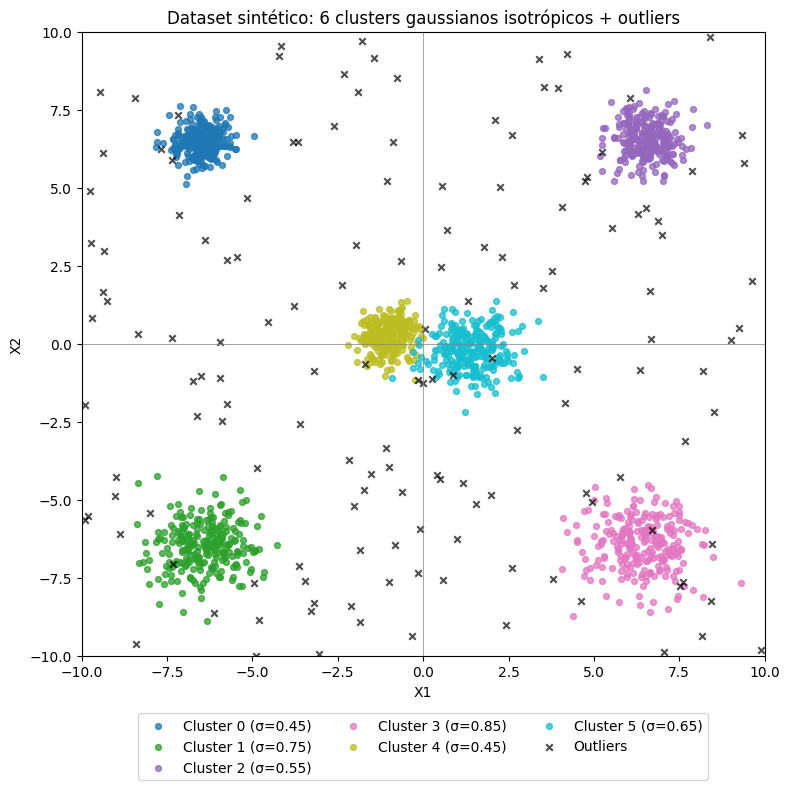

In [161]:
fig, ax = plt.subplots(figsize=(8, 8))

colors = cm.tab10(np.linspace(0, 1, n_clusters_verdaderos))

for i in range(n_clusters_verdaderos):
    mask = y_true_all == i
    ax.scatter(X_all[mask, 0], X_all[mask, 1], s=18, color=colors[i],
               label=f"Cluster {i} (σ={sigmas[i]})", alpha=0.75)

mask_out = y_true_all == -1
ax.scatter(X_all[mask_out, 0], X_all[mask_out, 1], s=22, color="black",
           marker="x", label="Outliers", alpha=0.7)

ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.axhline(0, color="gray", lw=0.5)
ax.axvline(0, color="gray", lw=0.5)
ax.set_xlabel("X1")
ax.set_ylabel("X2")
ax.set_title("Dataset sintético: 6 clusters gaussianos isotrópicos + outliers")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3)
plt.tight_layout()
plt.show()


**Observaciones esperadas del gráfico:**

- Los clusters 0, 1, 2 y 3 (esquinas) están bien separados entre sí.
- Los clusters 4 y 5 (centro) están **cerca uno del otro y se superponen parcialmente** — cumpliendo el requisito 4.
- Los clusters con **σ más grande** (1, 3) se ven más "dispersos" (menos densos) que los de **σ más pequeña** (0, 4), aunque tengan el mismo número de puntos — esa es la diferencia de densidad solicitada.
- Los outliers (x negras) están dispersos de forma **uniforme** por todo el cuadro `[-10, 10] x [-10, 10]`, sin concentrarse en ninguna zona.

---


## 3. Preprocesamiento: remoción de outliers

### 3.1 ¿Por qué remover los outliers antes de aplicar K-Means?

K-Means calcula cada centroide como el **promedio** de los puntos asignados a ese cluster. El promedio es una medida **muy sensible a valores extremos**: un solo outlier alejado puede desplazar considerablemente un centroide y distorsionar la partición de todo el dataset. Por eso, antes de aplicar el algoritmo, conviene **detectar y remover** los puntos atípicos.

### 3.2 Detección con *Local Outlier Factor* (LOF)

En un escenario real **no conocemos** qué puntos son outliers (nosotros sí lo sabemos porque los generamos, pero vamos a fingir que no). Usamos **Local Outlier Factor (LOF)**, un método no supervisado que compara la densidad local de cada punto con la de sus vecinos: los puntos en regiones de **baja densidad relativa** (comparados con su vecindario) se marcan como outliers.

Usamos como referencia la **proporción real de outliers que inyectamos** (`contamination`) para fijar el umbral de sensibilidad del método — esto es razonable en el taller porque queremos evaluar el algoritmo, no ajustar hiperparámetros de LOF.


In [162]:
contaminacion_estimada = n_outliers / len(X_all)
print(f"Proporción de outliers inyectados: {contaminacion_estimada:.3f}")

lof = LocalOutlierFactor(n_neighbors=50, contamination=contaminacion_estimada)
es_inlier = lof.fit_predict(X_all)          # 1 = inlier, -1 = outlier (según LOF)
lof_scores = lof.negative_outlier_factor_

mask_inlier = es_inlier == 1

X_clean = X_all[mask_inlier]
y_true_clean = y_true_all[mask_inlier]

print(f"Puntos originales: {len(X_all)}")
print(f"Puntos detectados como inliers (se conservan): {len(X_clean)}")
print(f"Puntos removidos (outliers detectados): {len(X_all) - len(X_clean)}")


Proporción de outliers inyectados: 0.091
Puntos originales: 1650
Puntos detectados como inliers (se conservan): 1500
Puntos removidos (outliers detectados): 150


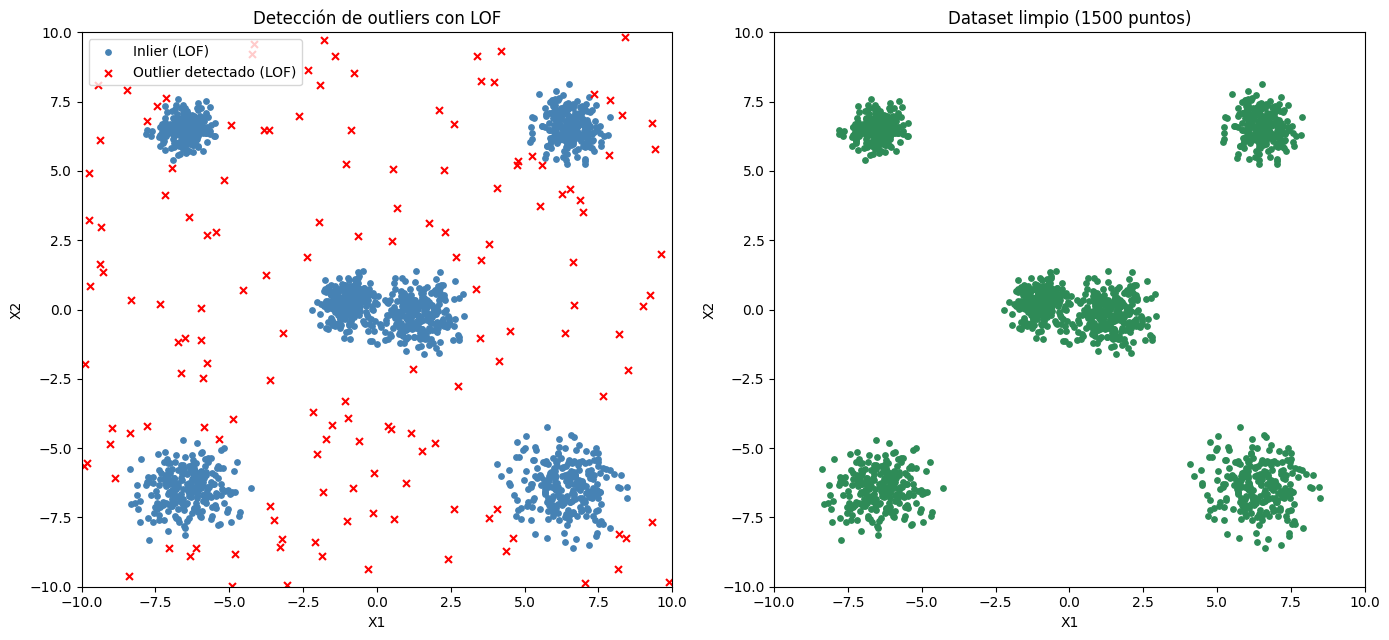

Outliers reales correctamente detectados (TP): 127 / 150
Puntos de cluster real removidos por error (FP): 23
Outliers reales que NO fueron detectados (FN): 23


In [163]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6.5))

axes[0].scatter(X_all[mask_inlier, 0], X_all[mask_inlier, 1], s=15, color="steelblue", label="Inlier (LOF)")
axes[0].scatter(X_all[~mask_inlier, 0], X_all[~mask_inlier, 1], s=25, color="red", marker="x", label="Outlier detectado (LOF)")
axes[0].set_xlim(-10, 10); axes[0].set_ylim(-10, 10)
axes[0].set_title("Detección de outliers con LOF")
axes[0].legend()

axes[1].scatter(X_clean[:, 0], X_clean[:, 1], s=15, color="seagreen")
axes[1].set_xlim(-10, 10); axes[1].set_ylim(-10, 10)
axes[1].set_title(f"Dataset limpio ({len(X_clean)} puntos)")

for ax in axes:
    ax.set_xlabel("X1"); ax.set_ylabel("X2")
plt.tight_layout()
plt.show()

# Qué tan bien coincide la detección de LOF con los outliers reales
verdaderos_outliers = (y_true_all == -1)
detectados_outliers = (~mask_inlier)
tp = np.sum(verdaderos_outliers & detectados_outliers)
fp = np.sum(~verdaderos_outliers & detectados_outliers)
fn = np.sum(verdaderos_outliers & ~detectados_outliers)
print(f"Outliers reales correctamente detectados (TP): {tp} / {verdaderos_outliers.sum()}")
print(f"Puntos de cluster real removidos por error (FP): {fp}")
print(f"Outliers reales que NO fueron detectados (FN): {fn}")


LOF no es perfecto: puede remover por error algunos puntos de clusters legítimos que caen en zonas de baja densidad (por ejemplo, en el borde de un cluster disperso) y puede dejar pasar algún outlier que, por azar, cayó cerca de un cluster. Aun así, el dataset resultante (`X_clean`) queda mucho más limpio que el original, que es justamente el objetivo del preprocesamiento.

A partir de aquí, **todo el análisis de K-Means se hace sobre `X_clean`** (outliers removidos).

---


## 4. Exploración de K-Means para K = 2 a 12

Ajustamos un modelo de K-Means para cada valor de **K** entre 2 y 12, y guardamos las métricas necesarias para los tres métodos de selección de K que aplicaremos después:

- **Inercia** (`inertia_`): suma de las distancias al cuadrado de cada punto a su centroide → insumo del **método del codo**.
- **Silhouette score**: qué tan bien separado y compacto está cada cluster → **método de Silhouette**.
- **Etiquetas predichas** (`labels_`): se usarán para comparar contra las etiquetas verdaderas (**ground truth**) con ARI y NMI.


In [164]:
K_range = range(2, 13)   # de 2 a 12 clusters

resultados = {
    "k": [],
    "inertia": [],
    "silhouette": [],
    "labels": [],
    "modelo": [],
}

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = kmeans.fit_predict(X_clean)

    resultados["k"].append(k)
    resultados["inertia"].append(kmeans.inertia_)
    resultados["silhouette"].append(silhouette_score(X_clean, labels_k))
    resultados["labels"].append(labels_k)
    resultados["modelo"].append(kmeans)

df_resultados = pd.DataFrame({
    "k": resultados["k"],
    "inertia": resultados["inertia"],
    "silhouette": resultados["silhouette"],
})
df_resultados


,k,inertia,silhouette
0,2,52209.660864,0.373349
1,3,32749.095652,0.557611
2,4,15362.600093,0.695853
3,5,1887.683453,0.843737
4,6,1135.212866,0.779242
5,7,1013.126009,0.696807
6,8,906.748089,0.615950
7,9,835.793111,0.618962
8,10,769.543903,0.569453
9,11,720.133551,0.472964


### 4.1 Visualización rápida de algunos valores de K

Antes de entrar en las métricas, es útil **ver** cómo cambia la partición del espacio según crece K.


In [177]:
def graficar_clusters_k(k_list, n_rows=2, n_cols=3, figsize=(15, 8)):
    fig, axes = plt.subplots(n_rows, n_cols, figsize=figsize)
    axes = axes.ravel()

    for i, k in enumerate(k_list):
        ax = axes[i]
        idx = list(K_range).index(k)
        labels_k = resultados["labels"][idx]
        centroids_k = resultados["modelo"][idx].cluster_centers_

        ax.scatter(X_clean[:, 0], X_clean[:, 1], c=labels_k, cmap="tab20", s=12)
        ax.scatter(centroids_k[:, 0], centroids_k[:, 1], c="red", marker="x", s=120)
        ax.set_xlim(-10, 10)
        ax.set_ylim(-10, 10)
        ax.set_title(f"K = {k}", fontsize=12, fontweight="bold")
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")

    # Ocultar subplots vacíos si los hay
    for j in range(len(k_list), len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()

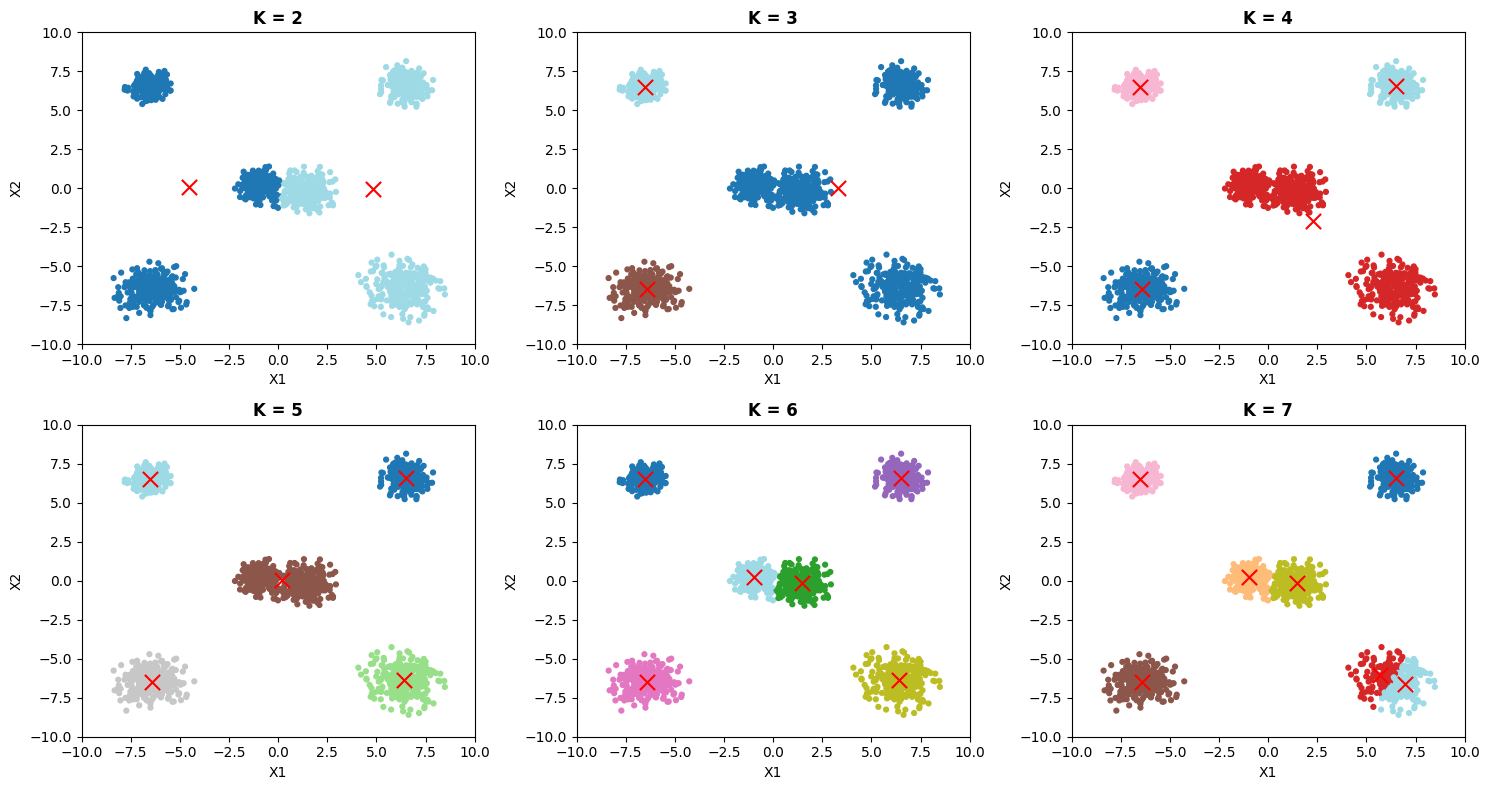

In [178]:
graficar_clusters_k(range(2, 8))

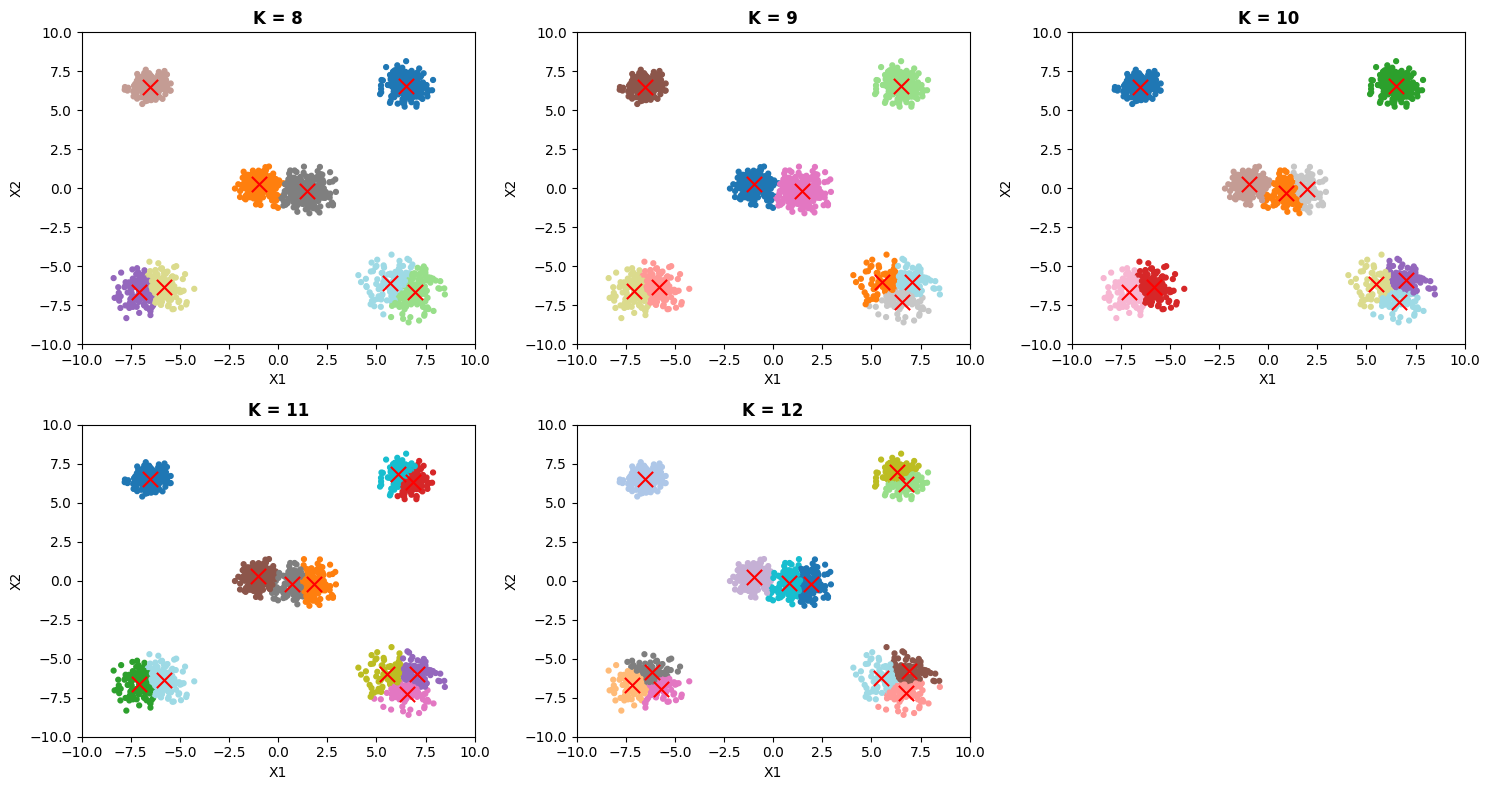

In [179]:
graficar_clusters_k(range(8, 13))

Con muy pocos clusters (K=2, K=4) el algoritmo **fusiona** grupos que en realidad son distintos. Con demasiados clusters (K=10, K=12) el algoritmo empieza a **partir artificialmente** clusters que ya eran homogéneos, sobre todo los más dispersos (mayor σ). El valor ideal debería estar cerca de **K = 6**, que es el número real de clusters que generamos — pero como los clusters 4 y 5 están parcialmente superpuestos, es interesante ver si los métodos automáticos logran "verlos" como dos grupos distintos o los tratan como uno solo.

---


## 5. Método del Codo (Elbow Method)

### 5.1 Fundamento

La **inercia** (`inertia_`) mide la suma de las distancias al cuadrado de cada punto a su centroide. Naturalmente, **la inercia siempre disminuye** a medida que aumentamos K (con más centroides, cada punto tiene uno más cerca). El truco es que, a partir de cierto valor de K, **agregar más clusters deja de reducir la inercia de forma significativa** — el gráfico forma un "codo" en ese punto, que se interpreta como el número óptimo de clusters.

✅ **Ventaja**: fácil de calcular e interpretar visualmente.
❌ **Desventaja**: el "codo" no siempre es evidente a simple vista; es un criterio algo subjetivo.

Para hacerlo más objetivo, además de mirar el gráfico calculamos el punto de **máxima curvatura** con un criterio simple: la mayor distancia perpendicular entre la curva de inercia y la línea recta que uniría el primer y el último punto.


K óptimo según el método del Codo: 5


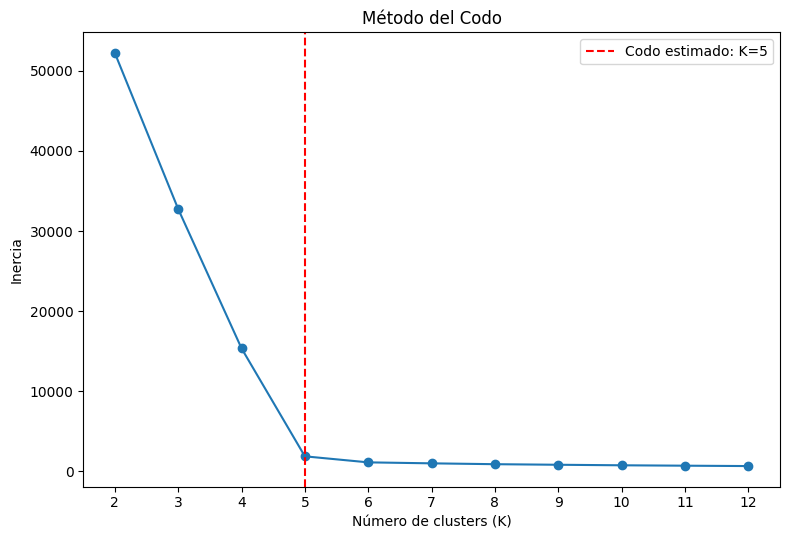

In [166]:
def encontrar_codo(k_values, inertias):
    # Estima el 'codo' como el punto de máxima distancia perpendicular
    # entre la curva y la línea recta que conecta el primer y último punto.
    k_values = np.array(k_values, dtype=float)
    inertias = np.array(inertias, dtype=float)

    # Normalizamos para que ambos ejes sean comparables
    k_norm = (k_values - k_values.min()) / (k_values.max() - k_values.min())
    inertia_norm = (inertias - inertias.min()) / (inertias.max() - inertias.min())

    p1 = np.array([k_norm[0], inertia_norm[0]])
    p2 = np.array([k_norm[-1], inertia_norm[-1]])
    linea = p2 - p1
    linea_norm = linea / np.linalg.norm(linea)

    distancias = []
    for x, y in zip(k_norm, inertia_norm):
        punto = np.array([x, y]) - p1
        proyeccion = np.dot(punto, linea_norm) * linea_norm
        perpendicular = punto - proyeccion
        distancias.append(np.linalg.norm(perpendicular))

    idx_codo = int(np.argmax(distancias))
    return k_values[idx_codo]

k_optimo_codo = int(encontrar_codo(df_resultados["k"], df_resultados["inertia"]))
print(f"K óptimo según el método del Codo: {k_optimo_codo}")

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(df_resultados["k"], df_resultados["inertia"], marker="o")
ax.axvline(k_optimo_codo, color="red", linestyle="--", label=f"Codo estimado: K={k_optimo_codo}")
ax.set_xlabel("Número de clusters (K)")
ax.set_ylabel("Inercia")
ax.set_title("Método del Codo")
ax.set_xticks(list(K_range))
ax.legend()
plt.tight_layout()
plt.show()


---


## 6. Método de Silhouette

### 6.1 Fundamento

El **coeficiente de Silhouette** de un punto compara:

- **a**: la distancia promedio del punto a los demás puntos de **su propio cluster** (cohesión).
- **b**: la distancia promedio del punto a los puntos del **cluster vecino más cercano** (separación).

$$ s = \frac{b - a}{\max(a, b)} $$

El coeficiente va de **-1 a 1**: valores cercanos a 1 indican que el punto está bien agrupado (cerca de su cluster, lejos de los demás); valores cercanos a 0 indican solapamiento entre clusters; valores negativos sugieren que el punto probablemente está en el cluster equivocado. El **K óptimo** es el que **maximiza el promedio del coeficiente de Silhouette** sobre todos los puntos.

✅ **Ventaja**: mide de forma objetiva y cuantitativa qué tan bien separados y compactos son los clusters, sin necesitar las etiquetas verdaderas.
❌ **Desventaja**: computacionalmente más costoso que el codo; en clusters solapados (como nuestros clusters 4 y 5) tiende a **penalizar** la separación en subgrupos, favoreciendo valores de K más bajos.


K óptimo según Silhouette: 5


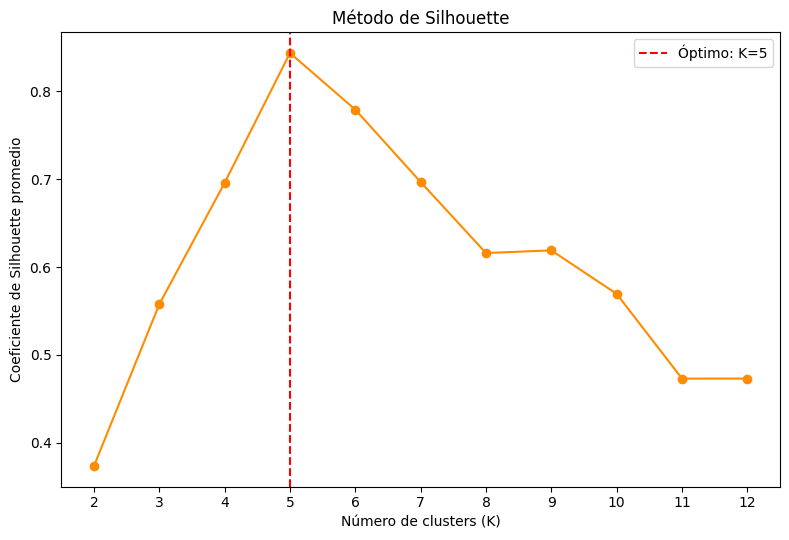

In [167]:
k_optimo_silhouette = df_resultados.loc[df_resultados["silhouette"].idxmax(), "k"]
print(f"K óptimo según Silhouette: {int(k_optimo_silhouette)}")

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(df_resultados["k"], df_resultados["silhouette"], marker="o", color="darkorange")
ax.axvline(k_optimo_silhouette, color="red", linestyle="--",
           label=f"Óptimo: K={int(k_optimo_silhouette)}")
ax.set_xlabel("Número de clusters (K)")
ax.set_ylabel("Coeficiente de Silhouette promedio")
ax.set_title("Método de Silhouette")
ax.set_xticks(list(K_range))
ax.legend()
plt.tight_layout()
plt.show()


### 6.2 Diagrama de Silhouette para el K óptimo

Además del promedio, es útil ver el **diagrama de silhouette por punto**: cada "hoja" representa un cluster, y su ancho/forma indica qué tan compacto y bien separado está.


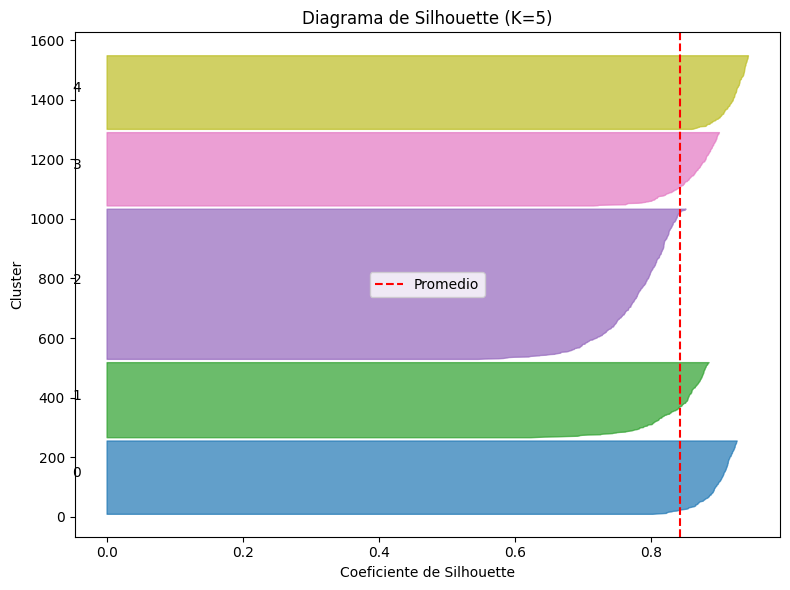

In [168]:
k_sil = int(k_optimo_silhouette)
idx_sil = list(K_range).index(k_sil)
labels_sil = resultados["labels"][idx_sil]
valores_silhouette = silhouette_samples(X_clean, labels_sil)

fig, ax = plt.subplots(figsize=(8, 6))
y_lower = 10
for i in range(k_sil):
    valores_cluster_i = np.sort(valores_silhouette[labels_sil == i])
    tamano_i = valores_cluster_i.shape[0]
    y_upper = y_lower + tamano_i
    color = cm.tab10(i / max(k_sil, 1))
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, valores_cluster_i,
                      facecolor=color, edgecolor=color, alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * tamano_i, str(i))
    y_lower = y_upper + 10

ax.axvline(x=np.mean(valores_silhouette), color="red", linestyle="--", label="Promedio")
ax.set_xlabel("Coeficiente de Silhouette")
ax.set_ylabel("Cluster")
ax.set_title(f"Diagrama de Silhouette (K={k_sil})")
ax.legend()
plt.tight_layout()
plt.show()


---


## 7. Método basado en Ground Truth (etiquetas verdaderas)

### 7.1 Fundamento

A diferencia del codo y de Silhouette (que **no** usan información externa), aquí aprovechamos que — únicamente porque nosotros generamos los datos — **conocemos el cluster real** de cada punto (`y_true_clean`). Esto nos permite comparar directamente la partición que produce K-Means contra la partición real, usando dos índices estándar:

- **Adjusted Rand Index (ARI)**: mide qué tan de acuerdo están dos particiones sobre **pares de puntos** (si dos puntos están juntos o separados en ambas particiones), corrigiendo por el azar. Va de -1 a 1 (1 = partición idéntica).
- **Normalized Mutual Information (NMI)**: mide cuánta **información** comparten las dos particiones (basado en entropía). Va de 0 a 1 (1 = partición idéntica).

Ambos índices son **invariantes a cómo se numeran los clusters** (no importa si el cluster que K-Means llama "3" corresponde al cluster real "0"; el índice igual los empareja correctamente).

El **K óptimo según este método** es el que **maximiza ARI (o NMI)** frente a las etiquetas reales. Nótese que esta comparación solo es posible porque estamos en un entorno controlado de laboratorio: en un problema real casi nunca tendríamos las etiquetas verdaderas (si las tuviéramos, usaríamos clasificación supervisada en lugar de clustering).

*Nota:* como los outliers no tienen un cluster real asociado, la comparación se hace solo sobre los puntos de `X_clean` cuya etiqueta verdadera es distinta de -1 (es decir, excluyendo cualquier outlier que el LOF no haya logrado remover).


K óptimo según ARI: 6
K óptimo según NMI: 6


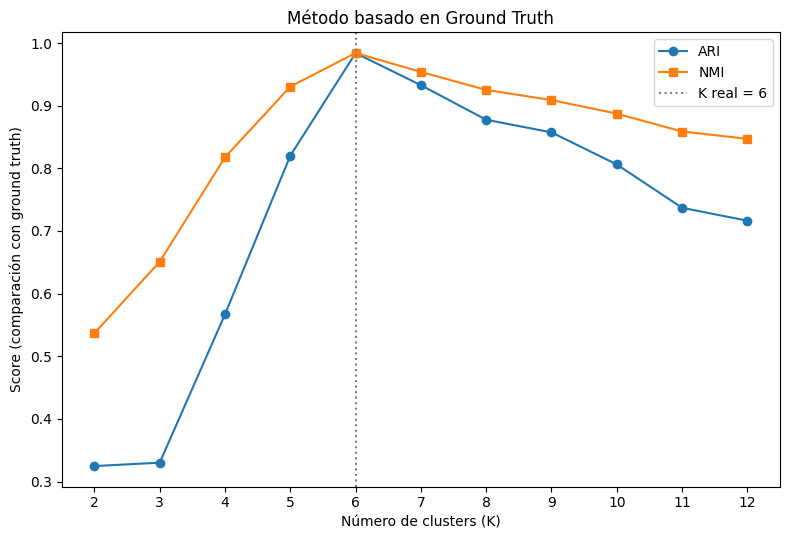

In [169]:
mask_con_etiqueta_real = y_true_clean != -1
y_true_valido = y_true_clean[mask_con_etiqueta_real]

ari_scores = []
nmi_scores = []

for idx_k, k in enumerate(K_range):
    labels_k = resultados["labels"][idx_k]
    labels_valido = labels_k[mask_con_etiqueta_real]

    ari = adjusted_rand_score(y_true_valido, labels_valido)
    nmi = normalized_mutual_info_score(y_true_valido, labels_valido)

    ari_scores.append(ari)
    nmi_scores.append(nmi)

df_resultados["ARI"] = ari_scores
df_resultados["NMI"] = nmi_scores

k_optimo_ari = df_resultados.loc[df_resultados["ARI"].idxmax(), "k"]
k_optimo_nmi = df_resultados.loc[df_resultados["NMI"].idxmax(), "k"]

print(f"K óptimo según ARI: {int(k_optimo_ari)}")
print(f"K óptimo según NMI: {int(k_optimo_nmi)}")

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.plot(df_resultados["k"], df_resultados["ARI"], marker="o", label="ARI")
ax.plot(df_resultados["k"], df_resultados["NMI"], marker="s", label="NMI")
ax.axvline(n_clusters_verdaderos, color="gray", linestyle=":", label=f"K real = {n_clusters_verdaderos}")
ax.set_xlabel("Número de clusters (K)")
ax.set_ylabel("Score (comparación con ground truth)")
ax.set_title("Método basado en Ground Truth")
ax.set_xticks(list(K_range))
ax.legend()
plt.tight_layout()
plt.show()


### 7.2 Matriz de confusión para el K óptimo (ARI)

Para entender mejor los errores, construimos la matriz de confusión entre los clusters reales y los clusters predichos por K-Means (con el K óptimo según ARI), **reasignando** las etiquetas predichas para que coincidan lo mejor posible con las reales (algoritmo húngaro, `linear_sum_assignment`), ya que K-Means numera los clusters de forma arbitraria.


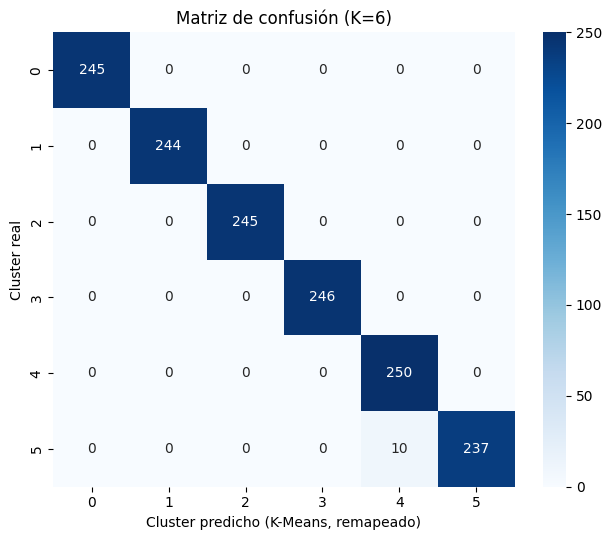

In [170]:
def remapear_etiquetas(y_true, y_pred):
    # Reasigna las etiquetas de y_pred para maximizar la coincidencia con y_true,
    # usando el algoritmo húngaro sobre la matriz de contingencia.
    etiquetas_true = np.unique(y_true)
    etiquetas_pred = np.unique(y_pred)
    matriz_costo = np.zeros((len(etiquetas_pred), len(etiquetas_true)))

    for i, lp in enumerate(etiquetas_pred):
        for j, lt in enumerate(etiquetas_true):
            matriz_costo[i, j] = -np.sum((y_pred == lp) & (y_true == lt))

    filas, columnas = linear_sum_assignment(matriz_costo)
    mapeo = {etiquetas_pred[f]: etiquetas_true[c] for f, c in zip(filas, columnas)}
    return np.array([mapeo[p] for p in y_pred])

k_gt = int(k_optimo_ari)
idx_gt = list(K_range).index(k_gt)
labels_gt = resultados["labels"][idx_gt][mask_con_etiqueta_real]
labels_gt_remapeadas = remapear_etiquetas(y_true_valido, labels_gt)

cm_matrix = confusion_matrix(y_true_valido, labels_gt_remapeadas)

plt.figure(figsize=(6.5, 5.5))
sns.heatmap(cm_matrix, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Cluster predicho (K-Means, remapeado)")
plt.ylabel("Cluster real")
plt.title(f"Matriz de confusión (K={k_gt})")
plt.tight_layout()
plt.show()


Si en la matriz de confusión aparecen números importantes **fuera de la diagonal** entre los clusters 4 y 5 (los que diseñamos superpuestos), es totalmente esperable: en la zona de solapamiento, algunos puntos están geométricamente más cerca del centroide del cluster vecino, aunque su origen real sea el otro.

---


## 8. Comparación de los tres métodos

Resumimos en una sola tabla y un solo gráfico los resultados de los tres métodos, junto con el número real de clusters (K=6) con el que generamos los datos.


In [171]:
resumen = pd.DataFrame({
    "Método": ["Codo (Elbow)", "Silhouette", "Ground Truth (ARI)", "Ground Truth (NMI)"],
    "K óptimo estimado": [k_optimo_codo, int(k_optimo_silhouette), int(k_optimo_ari), int(k_optimo_nmi)],
})
resumen["K real (referencia)"] = n_clusters_verdaderos
resumen


,Método,K óptimo estimado,K real (referencia)
0,Codo (Elbow),5,6
1,Silhouette,5,6
2,Ground Truth (ARI),6,6
3,Ground Truth (NMI),6,6


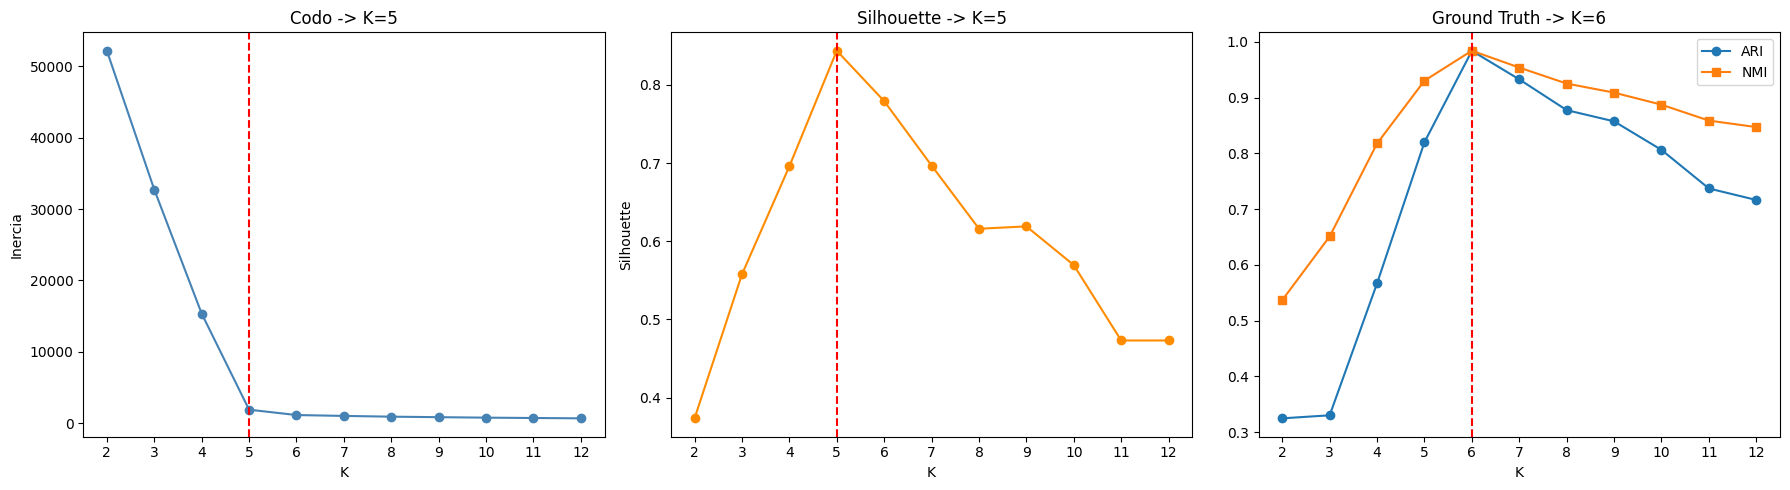

In [172]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(df_resultados["k"], df_resultados["inertia"], marker="o", color="steelblue")
axes[0].axvline(k_optimo_codo, color="red", linestyle="--")
axes[0].set_title(f"Codo -> K={k_optimo_codo}")
axes[0].set_xlabel("K"); axes[0].set_ylabel("Inercia")

axes[1].plot(df_resultados["k"], df_resultados["silhouette"], marker="o", color="darkorange")
axes[1].axvline(k_optimo_silhouette, color="red", linestyle="--")
axes[1].set_title(f"Silhouette -> K={int(k_optimo_silhouette)}")
axes[1].set_xlabel("K"); axes[1].set_ylabel("Silhouette")

axes[2].plot(df_resultados["k"], df_resultados["ARI"], marker="o", label="ARI")
axes[2].plot(df_resultados["k"], df_resultados["NMI"], marker="s", label="NMI")
axes[2].axvline(k_optimo_ari, color="red", linestyle="--")
axes[2].set_title(f"Ground Truth -> K={int(k_optimo_ari)}")
axes[2].set_xlabel("K"); axes[2].legend()

for ax in axes:
    ax.set_xticks(list(K_range))

plt.tight_layout()
plt.show()


### 8.1 Resultado final: clustering con K = 6 (el valor real)

Como cierre, visualizamos lado a lado la **partición real** y la **partición encontrada por K-Means con K=6**, para juzgar visualmente la calidad del resultado — especialmente en la zona de solapamiento.


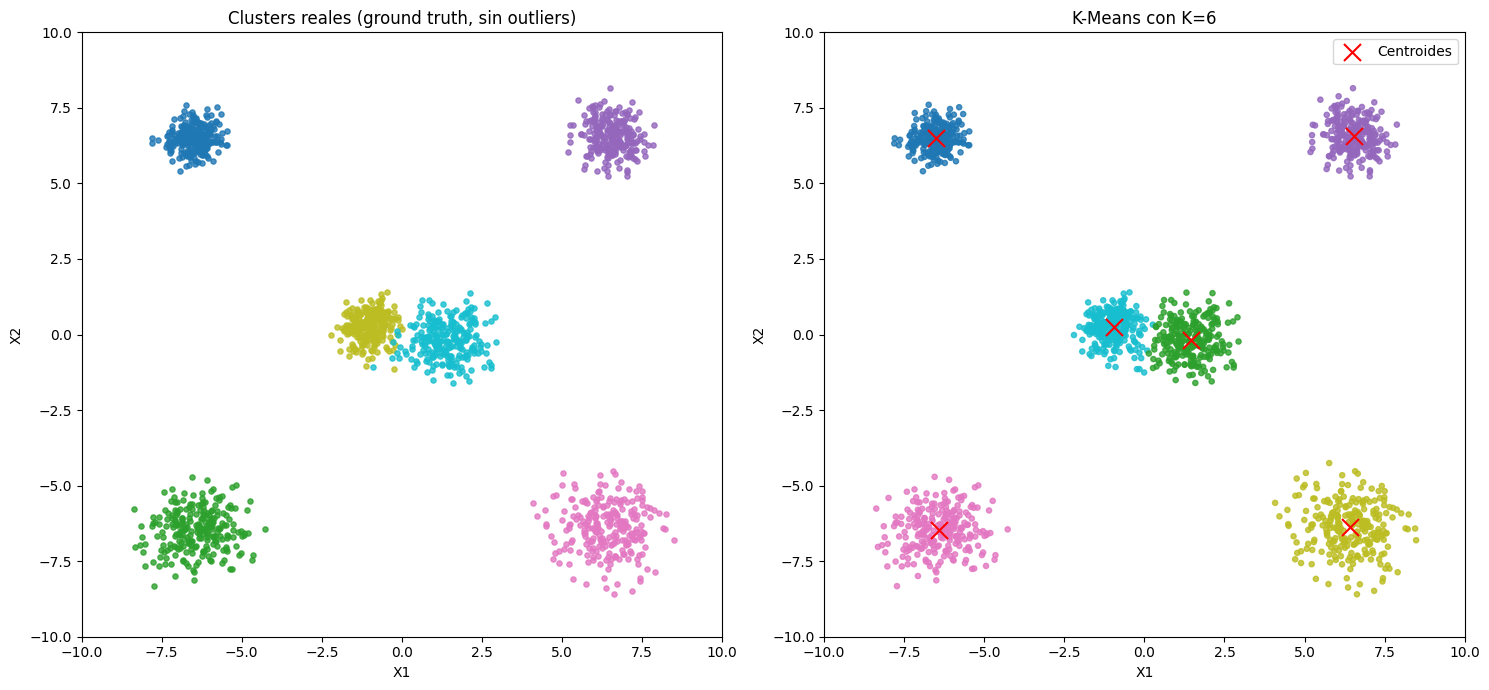

Silhouette con K=6: 0.7792
ARI con K=6:        0.9839
NMI con K=6:        0.9841


In [173]:
idx_k6 = list(K_range).index(6)
labels_k6 = resultados["labels"][idx_k6]
centroids_k6 = resultados["modelo"][idx_k6].cluster_centers_

fig, axes = plt.subplots(1, 2, figsize=(15, 7))

for i in range(n_clusters_verdaderos):
    mask = y_true_clean == i
    axes[0].scatter(X_clean[mask, 0], X_clean[mask, 1], s=14, color=colors[i], alpha=0.8)
axes[0].set_xlim(-10, 10); axes[0].set_ylim(-10, 10)
axes[0].set_title("Clusters reales (ground truth, sin outliers)")

axes[1].scatter(X_clean[:, 0], X_clean[:, 1], c=labels_k6, cmap="tab10", s=14, alpha=0.8)
axes[1].scatter(centroids_k6[:, 0], centroids_k6[:, 1], c="red", marker="x", s=150, label="Centroides")
axes[1].set_xlim(-10, 10); axes[1].set_ylim(-10, 10)
axes[1].set_title("K-Means con K=6")
axes[1].legend()

for ax in axes:
    ax.set_xlabel("X1"); ax.set_ylabel("X2")

plt.tight_layout()
plt.show()

print(f"Silhouette con K=6: {df_resultados.loc[df_resultados['k']==6, 'silhouette'].values[0]:.4f}")
print(f"ARI con K=6:        {df_resultados.loc[df_resultados['k']==6, 'ARI'].values[0]:.4f}")
print(f"NMI con K=6:        {df_resultados.loc[df_resultados['k']==6, 'NMI'].values[0]:.4f}")


---


## 9. Conclusiones del taller

- **Generación de datos**: se construyó un dataset sintético con 6 clusters gaussianos isotrópicos de igual tamaño (n) pero distinta σ (por lo tanto, distinta densidad), todos contenidos en el rango `[-10, 10]`, con dos clusters diseñados intencionalmente cerca y parcialmente superpuestos, y un conjunto de outliers uniformes.

- **Remoción de outliers**: usar un método no supervisado como LOF antes de aplicar K-Means es importante porque K-Means promedia posiciones para calcular centroides, y ese promedio es sensible a valores extremos. La detección no es perfecta (puede haber falsos positivos/negativos), pero mejora sustancialmente la calidad del dataset de entrada.

- **Método del Codo**: es rápido y fácil de calcular, pero el punto de inflexión puede ser ambiguo, especialmente cuando hay clusters solapados que "compiten" por reducir la inercia.

- **Silhouette**: da una medida más objetiva de la calidad de la partición, pero al ser una medida de **cohesión/separación geométrica**, tiende a **penalizar** la división de clusters solapados (como nuestros clusters 4 y 5) y puede favorecer un K **menor** al real.

- **Ground Truth (ARI / NMI)**: al comparar directamente con las etiquetas reales, es el método más preciso *cuando se dispone de esa información* — algo que casi nunca ocurre en un problema real de clustering (si tuviéramos las etiquetas, no necesitaríamos clustering). Aun así, es extremadamente útil en investigación y en la validación de algoritmos con datos sintéticos, como en este taller.

- **Conclusión general**: los tres métodos no necesariamente coinciden en el mismo K óptimo, y las discrepancias observadas (por ejemplo, si Silhouette sugiere un K distinto al real) son precisamente el resultado esperado de haber diseñado **a propósito** dos clusters que se solapan parcialmente. Esto ilustra una lección central del taller: **ningún método de selección de K es infalible por sí solo**; en la práctica conviene **combinar varios criterios** (y, siempre que sea posible, el conocimiento del dominio) antes de decidir el número final de clusters.

---
